In [1]:
url = "https://www.bchydro.com/info/res_hydromet/data/dow.txt?WT.ac=gmap_hd_dow&WT.mc_id=BCHGglMap&fbclid=IwdGRjcAQEkbpjbGNrBASROWV4dG4DYWVtAjExAHNydGMGYXBwX2lkDDM1MDY4NTUzMTcyOAABHkBbltwsye4LbDTWiUf04wp1ePSgoCygcDM8h6cdTD3nVePuD2W_yTkw01Kt_aem_5pq5hHCPiFgaCbgpqoYY_A"
# Download data
import requests
response = requests.get(url)
with open("dow.txt", "wb") as f:
	f.write(response.content)
	

c:\Users\ryanc\OneDrive\Desktop\courses\EECE567\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


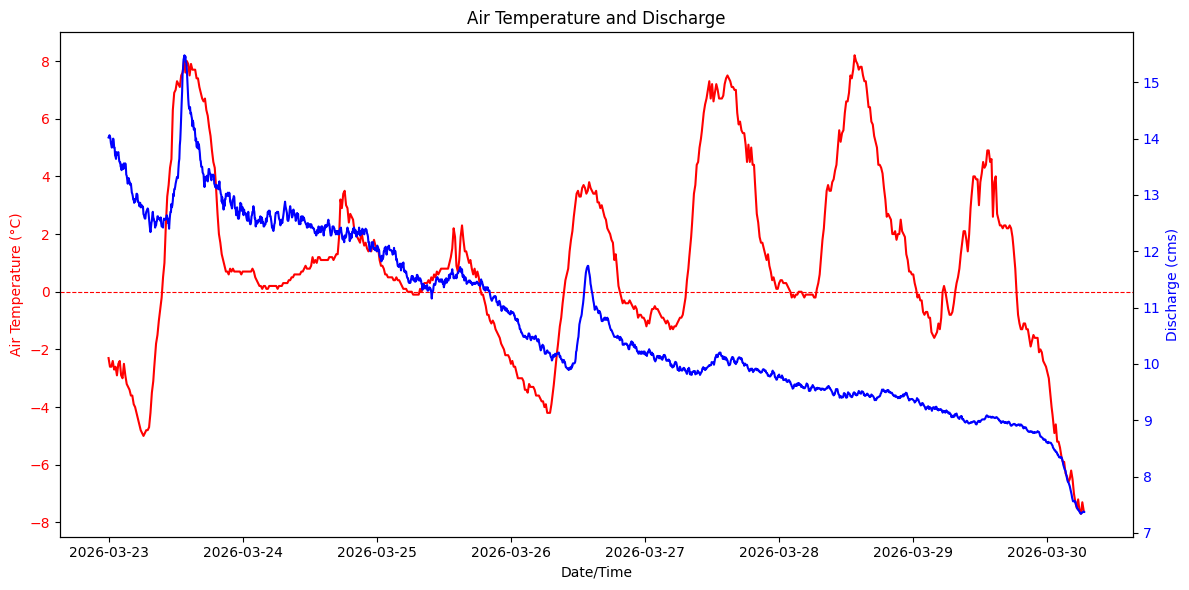

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt


# Define column specifications based on the fixed-width format
col_specs = [(0, 10), (11, 19), (28, 38), (41, 58)]
names = ['Date', 'Time', 'Air Temperature', 'Discharge']

# Read the data from the text file into a pandas DataFrame
df = pd.read_fwf('dow.txt', colspecs=col_specs, names=names, skiprows=10)

# Combine 'Date' and 'Time' columns into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Set the 'datetime' column as the index
df = df.set_index('datetime')

# Drop the original 'Date' and 'Time' columns
df = df.drop(['Date', 'Time'], axis=1)

# Convert 'Air Temperature' and 'Discharge' to numeric, coercing errors
df['Air Temperature'] = pd.to_numeric(df['Air Temperature'], errors='coerce')
df['Discharge'] = pd.to_numeric(df['Discharge'], errors='coerce')

# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Interpolate missing values for 'Air Temperature'
df['Air Temperature'] = df['Air Temperature'].interpolate(method='time')

# Smooth 'Discharge' using a rolling mean with a window of 5
df['Discharge'] = df['Discharge'].rolling(window=5, min_periods=1).mean()

# Plot 'Air Temperature' on the primary y-axis
ax1.plot(df.index, df['Air Temperature'], 'r-', label='Air Temperature')
ax1.set_xlabel('Date/Time')
ax1.set_ylabel('Air Temperature (°C)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.axhline(0, color='r', linestyle='--', linewidth=0.8)

# Create a secondary y-axis for 'Discharge'
ax2 = ax1.twinx()
ax2.plot(df.index, df['Discharge'], 'b-', label='Discharge')
ax2.set_ylabel('Discharge (cms)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Add title and legend
plt.title('Air Temperature and Discharge')
fig.tight_layout()
plt.show()